In [ ]:
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint


from network import NetCNN1D, NetCNN2D_CSP

from mne.decoding import CSP
from sklearn.model_selection import StratifiedKFold,  StratifiedShuffleSplit

import numpy as np
import sys, os

import dataset_NewEEG
from config_NewEEG import Config

import matplotlib.pyplot as plt


import pandas as pd
import pickle
import tqdm, logging, warnings

import train_evaluate



# Filter out info and warnings from TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
logging.getLogger('tensorflow').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')


config = Config()



# Choose from: 'CLeft', 'CRight', 'CUp' and 'CDown'
config.used_classes = [['CLeft'], ['CDown']]
config.session_type = 'S2'


config.test_session = 99  #9 # 3, 7


config.t_start = 0 
config.t_end = 3.0

config.window_size = 2.0




config.n_csp_components = 3


# All available channels = ['FC3', 'FCz', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CPz', 'CP4']
config.used_channels = ['FC3', 'FCz', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CPz', 'CP4']

config.model_type == '2D'




################# Changed in Adaptation #################

config.stride = 0.25


config.epochs = 100
config.batch_size = 32
config.n_splits = 2
config.val_size = 0.2


config.learning_rate = 2e-4
config.label_smoothing = 0.05
config.weight_decay = 2e-5



model = NetCNN2D_CSP(len(config.used_classes))
model.build((32, 3, 750, 1))
#model.summary()

model = NetCNN1D(len(config.used_classes))
model.build((32, 750, 3))
#model.summary()

In [2]:
X, y = [], []
for i in range(1, 12):
    if i == config.test_session:
        continue
    
    config.session_type = 'S2'
    Xi, yi = dataset_NewEEG.session_dataset(config, f'I{i:02d}')
    X.append(Xi)
    y.append(yi)

    config.session_type = 'S3'
    Xi, yi = dataset_NewEEG.session_dataset(config, f'I{i:02d}')
    X.append(Xi)
    y.append(yi)


X, y = np.concatenate(X), np.concatenate(y)

print(X.shape)
print(y.shape)

(653, 13, 750)
(653,)


  0%|          | 0/2 [00:00<?, ?it/s]

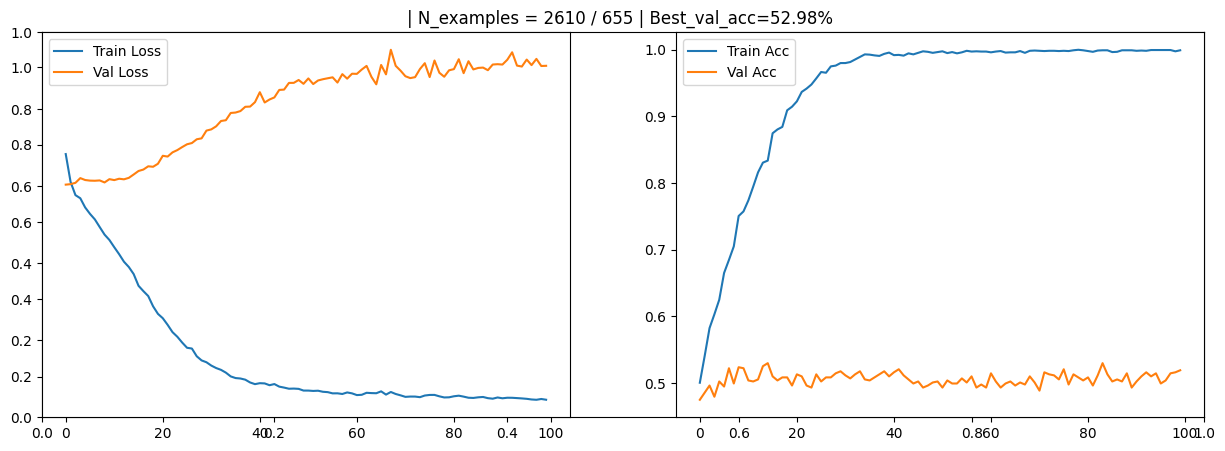

 50%|█████     | 1/2 [02:30<02:30, 150.85s/it]

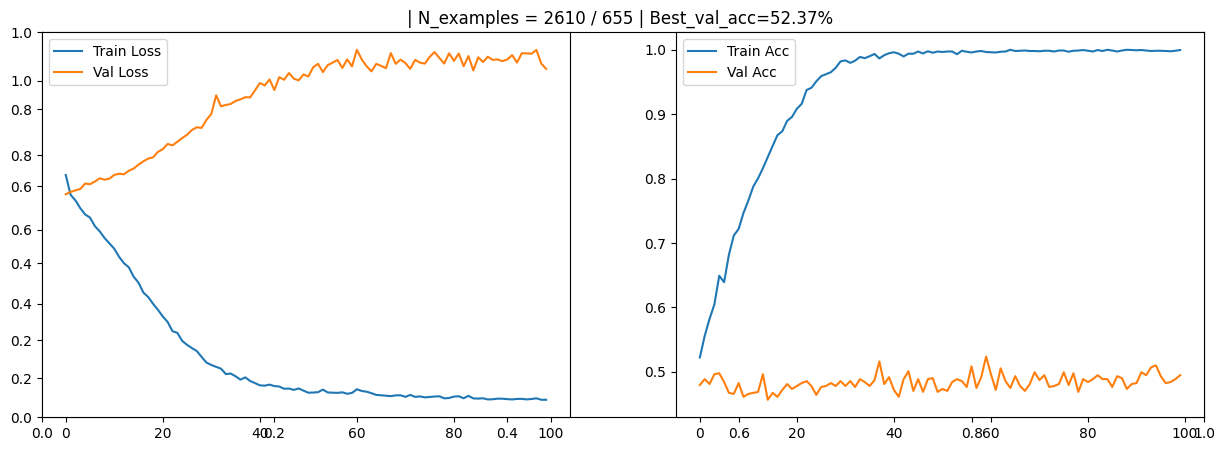

100%|██████████| 2/2 [04:55<00:00, 147.67s/it]


Best model saved  with validation accuracy: 1.0000



Average Best Validation accuracy = 100.00% +- 0.0





In [3]:
#crossValidation_KF = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
crossValidation_KF = StratifiedShuffleSplit(n_splits=config.n_splits, test_size=config.val_size, random_state=0)

                    

acc = []
Y_preds = []

shuffle_indices = np.random.permutation(len(y))



X = X[shuffle_indices]
y = y[shuffle_indices]


best_model = None
best_acc = 0
best_csp = None
val_accs_allFolds = []

for fold_idx, (train_index, valid_index) in tqdm.tqdm(enumerate(crossValidation_KF.split(X,y)), total = config.n_splits):
    
    if config.model_type == '2D':
        model = NetCNN2D_CSP(len(config.used_classes))
    else:
        model = NetCNN1D(len(config.used_classes))
    
    X_train, Y_train = X[train_index],  y[train_index]
    X_valid, Y_valid = X[valid_index], y[valid_index]

    model, csp, val_acc = train_evaluate.train_evalute(config, X_train, Y_train, X_valid, Y_valid, model, plot_graphs=True)

    val_accs_allFolds.append(val_acc)
    if val_acc > best_acc:
        best_acc = val_acc
        best_model = model
        best_csp = csp 



if best_model is not None:
    best_model.save(os.path.join('saved_models','best_model.tf'), save_format='tf')
    print(f"Best model saved  with validation accuracy: {best_acc:.4f}")

    with open(os.path.join('saved_models','csp.pkl'), 'wb') as f:
        pickle.dump(best_csp, f)


print("\n\n ========================================= \n")
print(f"Average Best Validation accuracy = {100*np.mean(val_accs_allFolds):.2f}% +- {100*np.std(val_accs_allFolds):.1f}")
print("\n\n ========================================= \n")

In [4]:
# Evaluate Pre-training model on new Session,  without any adapation


model = tf.keras.models.load_model(os.path.join('saved_models', 'best_model.tf'))
model.trainable = False

with open(os.path.join('saved_models', 'csp.pkl'), 'rb') as f:
    csp_trained = pickle.load(f)




config.test_session = 11

X, y = dataset_NewEEG.session_dataset(config, f'I{config.test_session:02d}')
X, y = dataset_NewEEG.slice_EEG_epoch(config, X, y)


X_csp_trained = csp_trained.transform(X)

if config.model_type == '2D':
    X_csp_trained = np.expand_dims(X_csp_trained, 3)
else:
    X_csp_trained = X_csp_trained.transpose(0, 2, 1)


y = tf.keras.utils.to_categorical(y, num_classes = len(config.used_classes))

print(f"\nWith CSP on other sessions =  {model.evaluate(X_csp_trained, y)[1]:.2f} \n")








X, y = dataset_NewEEG.session_dataset(config, f'I{config.test_session:02d}')
X, y = dataset_NewEEG.slice_EEG_epoch(config, X, y)

old_stdout = sys.stdout
sys.stdout = open(os.devnull, 'w')

csp = CSP(n_components=config.n_csp_components, reg=None, log=None, norm_trace=False, transform_into='csp_space')
X = csp.fit_transform(X, y)

if config.model_type == '2D':
    X = np.expand_dims(X, 3)
else:
    X = X_csp_trained.X(0, 2, 1)

y = tf.keras.utils.to_categorical(y, num_classes = len(config.used_classes))

sys.stdout.close()
sys.stdout = old_stdout



print(f"\nWith New CSP on test session =  {model.evaluate(X, y)[1]:.2f} \n")

6/6 [==============================] - 0s 4ms/step - loss: 0.2106 - acc: 0.9412

With CSP on other sessions =  0.94 

6/6 [==============================] - 0s 4ms/step - loss: 1.3727 - acc: 0.5353

With New CSP on test session =  0.54 

